In [ ]:
!pip install textblob nltk
import nltk
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from textblob import TextBlob
from nltk.corpus import stopwords
from collections import Counter


In [ ]:
# Replace with your file path
df = pd.read_csv("/content/drive/MyDrive/Crio.do/chatgpt_reviews.csv")

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Handle missing reviews
df['review'] = df['review'].fillna("")

# Convert date if present
if 'review_date' in df.columns:
    df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

# Ensure ratings numeric
if 'ratings' in df.columns:
    df['ratings'] = pd.to_numeric(df['ratings'], errors='coerce')

df.head()


,review_id,review,ratings,review_date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [ ]:
def get_sentiment(text):
    blob = TextBlob(str(text))
    return pd.Series({
        'polarity': blob.sentiment.polarity,      # -1 (neg) → +1 (pos)
    })

df[['polarity']] = df['review'].apply(get_sentiment)
df.head()

# Categorize
def label_sentiment(p):
    if p > 0.1:
        return "Positive"
    elif p < -0.1:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['polarity'].apply(label_sentiment)

df[['review','ratings','polarity','sentiment']].head()


,review,ratings,polarity,sentiment
0,good,5,0.7000,Positive
1,good,5,0.7000,Positive
2,nice app,5,0.6000,Positive
3,"nice, ig",5,0.6000,Positive
4,"this is a great app, the bot is so accurate to...",5,0.4125,Positive


/tmp/ipython-input-1289338178.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis')


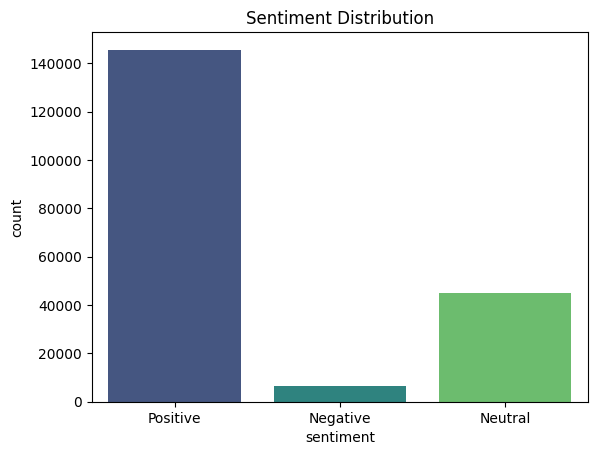

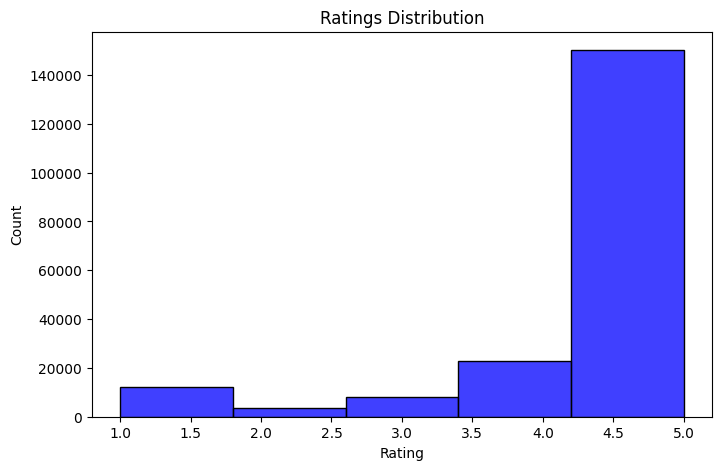

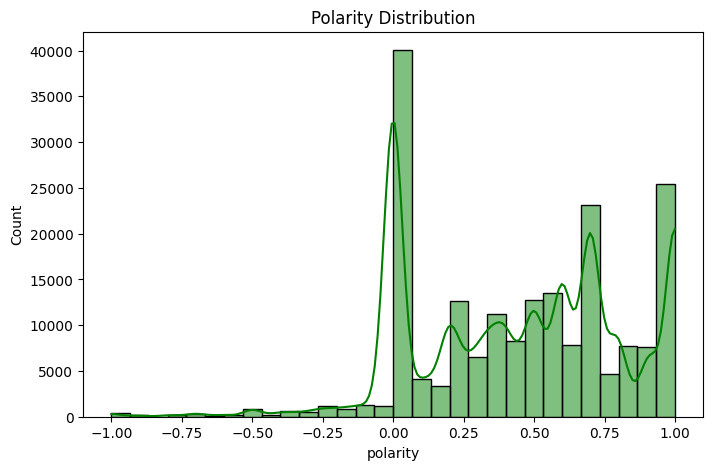

In [ ]:
sns.countplot(data=df, x='sentiment', palette='viridis')
plt.title("Sentiment Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['ratings'], bins=5, kde=False, color="blue")
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['polarity'], bins=30, kde=True, color="green")
plt.title("Polarity Distribution")
plt.show()




[('app', 51475), ('good', 39890), ('best', 18508), ('nice', 13939), ('great', 12061), ('helpful', 11763), ('chatgpt', 10395), ('like', 9248), ('amazing', 8830), ('love', 8729), ('useful', 7694), ('use', 7545), ('really', 7421), ('excellent', 6233), ('chat', 6205), ('gpt', 5240), ('awesome', 5142), ('work', 4443), ('help', 4362), ('information', 4274)]


/tmp/ipython-input-569127881.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=uni_df, x="count", y="word", palette="mako")


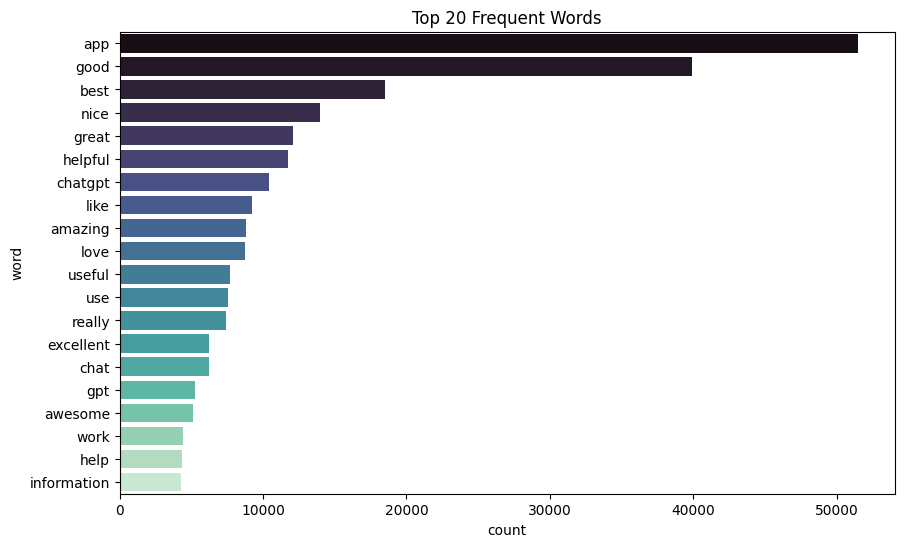

In [ ]:
# text analysis for words and bigrams extraction
stop_words = set(stopwords.words("english"))

#tokenize text into words and return words if not in stopwords and len>2
def tokenize(text):
    words = re.findall(r'\b\w+\b', text.lower())
    return [w for w in words if w not in stop_words and len(w) > 2]

# Collect tokens
tokens = []
for review in df['review']:
    tokens.extend(tokenize(review))

# Top 20 unigrams using counter
unigram_counts = Counter(tokens).most_common(20)
print(unigram_counts)
uni_df = pd.DataFrame(unigram_counts, columns=["word","count"])

plt.figure(figsize=(10,6))
sns.barplot(data=uni_df, x="count", y="word", palette="mako")
plt.title("Top 20 Frequent Words")
plt.show()



[(('good', 'app'), 6028), (('best', 'app'), 5477), (('chat', 'gpt'), 3423), (('nice', 'app'), 3380), (('great', 'app'), 3184), (('love', 'app'), 1885), (('app', 'ever'), 1842), (('amazing', 'app'), 1583), (('useful', 'app'), 1231), (('really', 'good'), 1197), (('easy', 'use'), 1154), (('app', 'good'), 1119), (('helpful', 'app'), 1116), (('really', 'helpful'), 1022), (('excellent', 'app'), 890), (('app', 'helpful'), 839), (('like', 'app'), 808), (('app', 'really'), 796), (('one', 'best'), 758), (('helps', 'lot'), 719)]
            bigram
0         good app
1         best app
2         chat gpt
3         nice app
4        great app
5         love app
6         app ever
7      amazing app
8       useful app
9      really good
10        easy use
11        app good
12     helpful app
13  really helpful
14   excellent app
15     app helpful
16        like app
17      app really
18        one best
19       helps lot
            bigram  count
0         good app   6028
1         best app   5477

/tmp/ipython-input-1066509284.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bi_df, x="count", y="bigram", palette="viridis")


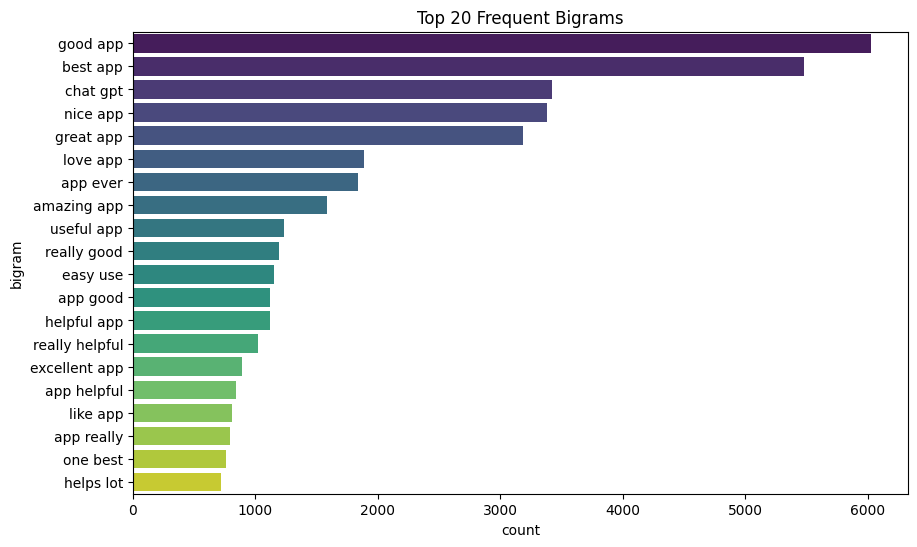

In [ ]:
# Bigrams
bigrams = []
for review in df['review']:
    words = tokenize(review)
    for i in range(len(words)-1):
        bigrams.append((words[i], words[i+1]))

bigram_counts = Counter(bigrams).most_common(20)
print(bigram_counts)
bi_df = pd.DataFrame([" ".join(b) for b,c in bigram_counts], columns=["bigram"])
print(bi_df)
bi_df["count"] = [c for b,c in bigram_counts]
print(bi_df)

plt.figure(figsize=(10,6))
sns.barplot(data=bi_df, x="count", y="bigram", palette="viridis")
plt.title("Top 20 Frequent Bigrams")
plt.show()


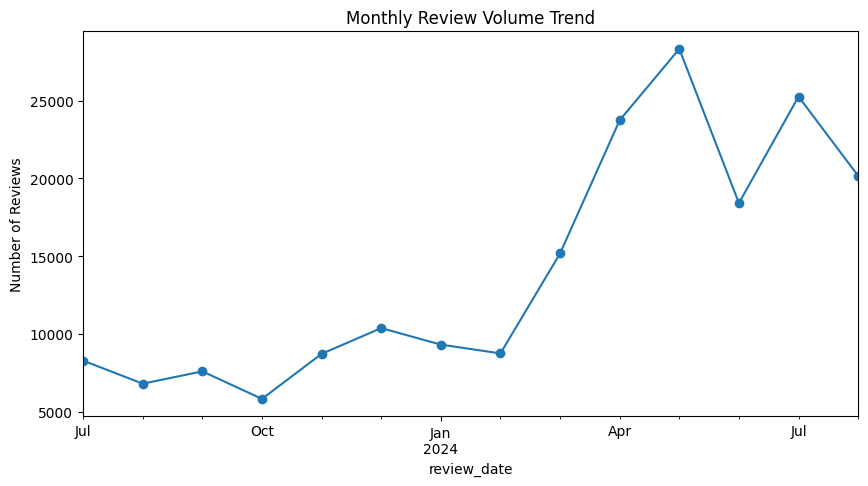

In [ ]:
if 'review_date' in df.columns:
    monthly_reviews = df.groupby(df['review_date'].dt.to_period('M'))['ratings'].count()
    monthly_reviews.plot(kind='line', marker='o', figsize=(10,5))
    plt.title("Monthly Review Volume Trend")
    plt.ylabel("Number of Reviews")
    plt.show()


